<a href="https://colab.research.google.com/github/Kccev802/kccev/blob/main/lab5_khadijah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# lab 5 - mini project
**by khadijah alharbi 4456770**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import util
from scipy.ndimage import uniform_filter, median_filter, generic_filter

In [2]:
# --- 1. Load Image ---
path = "/content/تنزيل (2).jpg"
img_raw = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
img = img_raw.astype(np.float32) / 255.0

In [3]:
# Helper function for MSE (Mean Squared Error)
def get_mse(a, b):
    return float(np.mean((a - b)**2))

In [4]:
# --- 2. Gaussian Noise & Restoration ---
# Add Gaussian Noise
rng = np.random.default_rng(0)
gauss_noise = rng.normal(0, 0.08, img.shape).astype(np.float32)
img_gauss = np.clip(img + gauss_noise, 0, 1)

In [5]:
# Arithmetic Mean Filter (3x3)
out_arithmetic = uniform_filter(img_gauss, size=3)

In [6]:
# Geometric Mean Filter (3x3)
def geometric_mean(im, size=3):
    log_im = np.log(np.clip(im, 1e-6, 1.0))
    return np.exp(uniform_filter(log_im, size=size))
out_geometric = geometric_mean(img_gauss, size=3)

In [7]:
# --- 3. Salt and Pepper Noise & Restoration ---
# Add Salt and Pepper Noise
img_sp = util.random_noise(img, mode="s&p", amount=0.08).astype(np.float32)

In [8]:
# Median Filter (3x3)
out_median = median_filter(img_sp, size=3)

In [9]:
# Contraharmonic Filter (Function for Q)
def contraharmonic(im, size=3, Q=1.5):
    def f(window):
        w = np.array(window, dtype=np.float32) + 1e-6
        return np.sum(w**(Q+1)) / np.sum(w**Q)
    return generic_filter(im, f, size=size)

In [10]:
# Using Q=1.5 to reduce pepper and Q=-1.5 to reduce salt
out_contra = contraharmonic(img_sp, size=3, Q=1.5)

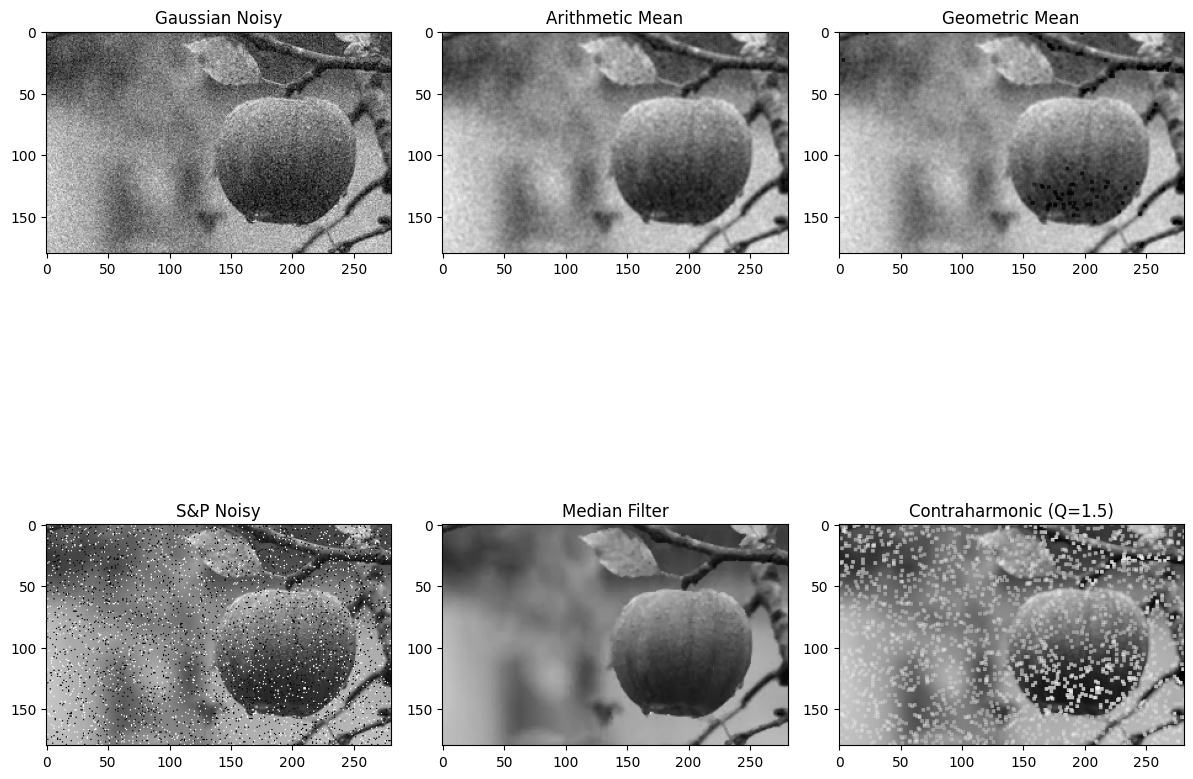

In [11]:
# --- 4. Visualization ---
plt.figure(figsize=(16, 10))

# Gaussian Results
plt.subplot(2, 4, 1); plt.imshow(img_gauss, cmap='gray'); plt.title("Gaussian Noisy")
plt.subplot(2, 4, 2); plt.imshow(out_arithmetic, cmap='gray'); plt.title("Arithmetic Mean")
plt.subplot(2, 4, 3); plt.imshow(out_geometric, cmap='gray'); plt.title("Geometric Mean")

# S&P Results
plt.subplot(2, 4, 5); plt.imshow(img_sp, cmap='gray'); plt.title("S&P Noisy")
plt.subplot(2, 4, 6); plt.imshow(out_median, cmap='gray'); plt.title("Median Filter")
plt.subplot(2, 4, 7); plt.imshow(out_contra, cmap='gray'); plt.title("Contraharmonic (Q=1.5)")

plt.tight_layout()
plt.show()

In [12]:
# --- 5. MSE Evaluation ---
print(f"Gaussian Noisy MSE: {get_mse(img, img_gauss):.4f}")
print(f"Arithmetic Mean MSE: {get_mse(img, out_arithmetic):.4f}")
print(f"Geometric Mean MSE: {get_mse(img, out_geometric):.4f}")
print("-" * 30)
print(f"S&P Noisy MSE: {get_mse(img, img_sp):.4f}")
print(f"Median Filter MSE: {get_mse(img, out_median):.4f}")

Gaussian Noisy MSE: 0.0064
Arithmetic Mean MSE: 0.0014
Geometric Mean MSE: 0.0019
------------------------------
S&P Noisy MSE: 0.0232
Median Filter MSE: 0.0007


# Project Discussion

* **Noise Models:** Gaussian noise was added to simulate electronic circuit noise, while Salt & Pepper noise simulated transmission errors.

* **Performance:** The Median filter showed the best visual results and lowest MSE for S&P noise because it effectively ignores outliers.

* **Trade-off:** Arithmetic Mean reduced Gaussian noise but caused significant edge blurring, whereas Geometric Mean preserved slightly more detail.

# Reflection question
1. **Why is restoration more objective than enhancement?**


Restoration is objective because it is based on mathematical models of degradation to return the image to its original state. Enhancement is subjective because it focuses on making the image "look better" to the human eye.

**2. Why must noise models be identified before restoration?**


Different noise types require different filters. For example, a Mean filter works for Gaussian noise but fails completely for Salt & Pepper noise, which needs a Median filter.

**3. Why is there no single best denoising filter?**


 There is always a trade-off between removing noise and preserving fine details (edges). A filter that removes noise very well might also blur important edges in the image